##Paso #1: Importar y activar librerias


---



In [ ]:
!pip install tensorflow
import os
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, Concatenate, BatchNormalization
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from google.colab.patches import cv2_imshow  # Importa cv2_imshow desde google.colab.patches
from PIL import Image
from skimage import io  # Importar la función io de skimage
from sklearn.metrics import mean_absolute_error, mean_squared_error

##Paso #2: Conectar a base de datos en Google Drive

---



In [ ]:
import os, zipfile
from google.colab import drive

drive.mount("/content/drive")

zip_path = "/content/drive/MyDrive/T.Final - DAVA/BodyM_dataset.zip"
extract_path = "/content/BodyM_dataset"
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(extract_path)

base_dir = extract_path
print("Base:", base_dir)
print("Subcarpetas:", os.listdir(base_dir)[:20])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/T.Final - DAVA/BodyM_dataset.zip'

# Paso #4: Ver estructura de datos

---



In [ ]:
# Base directory:
# Carpeta raíz donde está todo el dataset (train, testA, testB, etc.)
base_dir = "/content/BodyM_dataset"

# Train data paths
# # Carpeta del split de entrenamiento
train_dir = f'{base_dir}/train'
# CSV que mapea sujeto (subject) ↔ foto/imagen (photo)
train_subject_to_photo_map = f'{train_dir}/subject_to_photo_map.csv'
# CSV con metadata
train_hwg_metadata = f'{train_dir}/hwg_metadata.csv'
# CSV con medidas corporales
train_measurements = f'{train_dir}/measurements.csv'
# Carpeta que contiene máscaras (segmentación) asociadas a las imágenes
train_mask_dir = f'{train_dir}/mask'
# Carpeta con máscaras “left”
train_mask_left_dir = f'{train_dir}/mask_left'


# TestA data paths
# # Carpeta del split testA
testA_dir = f'{base_dir}/testA'
# Mapeo sujeto - foto para testA
testA_subject_to_photo_map = f'{testA_dir}/subject_to_photo_map.csv'
# Metadata para testA
testA_hwg_metadata = f'{testA_dir}/hwg_metadata.csv'
# Medidas/labels para testA
testA_measurements = f'{testA_dir}/measurements.csv'
# Máscaras para testA
testA_mask_dir = f'{testA_dir}/mask'
# Máscaras “left” para testA
testA_mask_left_dir = f'{testA_dir}/mask_left'


# TestB data paths
# Carpeta del split testB
testB_dir = f'{base_dir}/testB'
# Mapeo sujeto - foto para testB
testB_subject_to_photo_map = f'{testB_dir}/subject_to_photo_map.csv'
# Metadata para testB
testB_hwg_metadata = f'{testB_dir}/hwg_metadata.csv'
# Medidas/labels para testB
testB_measurements = f'{testB_dir}/measurements.csv'
# Máscaras para testB
testB_mask_dir = f'{testB_dir}/mask'
# Máscaras “left” para testB
testB_mask_left_dir = f'{testB_dir}/mask_left'

Este bloque realiza la carga de datos del dataset en pandas.

Para cada partición (train, testA, testB) se leen 3 archivos CSV:

* Mapa sujeto–foto (subject_to_photo_map): relaciona IDs de sujetos con sus imágenes.

* Metadata (hwg_metadata): atributos generales del sujeto.

* Medidas (measurements): variables objetivo (labels) con medidas corporales.

El resultado son DataFrames listos para combinarse y construir el dataset final de entrenamiento y evaluación.

In [ ]:
# Load train data CSVs
train_subject_to_photo_df = pd.read_csv(train_subject_to_photo_map)  # carga el CSV que relaciona sujeto (ID) con su(s) foto(s)
train_hwg_metadata_df = pd.read_csv(train_hwg_metadata)              # carga el CSV con metadata del sujeto (ej. height/weight/gender, etc.)
train_measurements_df = pd.read_csv(train_measurements)              # carga el CSV con las medidas corporales (labels/targets)

# Load testA data CSVs
testA_subject_to_photo_df = pd.read_csv(testA_subject_to_photo_map)  # lo mismo, pero para el split testA
testA_hwg_metadata_df = pd.read_csv(testA_hwg_metadata)              # metadata del split testA
testA_measurements_df = pd.read_csv(testA_measurements)              # medidas/targets del split testA

# Load testB data CSVs
testB_subject_to_photo_df = pd.read_csv(testB_subject_to_photo_map)  # lo mismo, pero para el split testB
testB_hwg_metadata_df = pd.read_csv(testB_hwg_metadata)              # metadata del split testB
testB_measurements_df = pd.read_csv(testB_measurements)              # medidas/targets del split testB

In [ ]:
# Unir los datos por 'subject_id' para obtener el photo_id, la altura, el peso y las medidas corporales en un solo DataFrame
train_data = train_subject_to_photo_df.merge(train_hwg_metadata_df, on='subject_id').merge(train_measurements_df, on='subject_id')

In [ ]:
# Definir las rutas de las imágenes usando rutas de Google Drive
train_data['frontal_image_path'] = train_mask_dir + '/' + train_data['photo_id'] + '.png'
train_data['lateral_image_path'] = train_mask_left_dir + '/' + train_data['photo_id'] + '.png'

# Definir las variables de entrada adicionales y las etiquetas objetivo
additional_inputs = train_data[['height_cm', 'weight_kg']].values  # height and weight
target_labels = train_data[['ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm',
                            'height', 'hip', 'leg-length', 'shoulder-breadth',
                            'shoulder-to-crotch', 'thigh', 'waist', 'wrist']].values

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.callbacks import LearningRateScheduler  # importado, pero en este bloque no se usa

# Entrada de imagen (frontal + lateral apiladas como 2 canales)
image_input = Input(shape=(224, 224, 2))

# ResNet50 como extractor de características para la imagen
# include_top=False: se quita la “cabeza” de clasificación
# weights=None: se entrena desde cero (sin pesos preentrenados)
resnet_base = ResNet50(include_top=False, weights=None, input_tensor=image_input)

# Aplana las características y crea capas densas para aprender una representación
x = Flatten()(resnet_base.output)
x = Dense(1024, activation='relu')(x)   # capa densa para aprender patrones
x = Dropout(0.5)(x)                     # dropout para reducir sobreajuste

# Entrada adicional (2 valores numéricos: altura y peso)
additional_input = Input(shape=(2,))
y = Dense(64, activation='relu')(additional_input)  # proyecta altura/peso a un espacio de características

# Combina (concatena) características de imagen + características de altura/peso
combined = Concatenate()([x, y])

# Capas finales para predecir las medidas corporales
z = Dense(512, activation='relu')(combined)
z = Dropout(0.5)(z)
output = Dense(14, activation='linear')(z)  # salida continua: 14 valores (medidas corporales)

# Define el modelo con dos entradas (imagen y altura/peso) y una salida (14 medidas)
model = Model(inputs=[image_input, additional_input], outputs=output)

# Define un learning rate con decaimiento exponencial (va bajando con los pasos)
initial_learning_rate = 0.001
lr_schedule = ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,   # cada cuántos pasos se aplica el decaimiento
    decay_rate=0.96,     # factor de reducción del learning rate
    staircase=True       # decaimiento por “escalones” (no continuo)
)

# Compila el modelo: optimizador Adam con ese learning rate, y pérdida MSE (regresión)
optimizer = Adam(learning_rate=lr_schedule)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae', 'accuracy'])


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.callbacks import ReduceLROnPlateau

reduce_lr = ReduceLROnPlateau(
    monitor='loss',      # Monitorea la pérdida de validación
    factor=0.5,              # Factor por el cual se reducirá la tasa de aprendizaje (nueva_lr = lr * factor)
    patience=50,              # Número de épocas sin mejora para reducir la tasa de aprendizaje
    min_lr=1e-6              # Tasa de aprendizaje mínima
)

def data_generator(data, batch_size=32, target_size=(224, 224)):
    while True:
        for start in range(0, len(data), batch_size):
            end = min(start + batch_size, len(data))
            batch_data = data[start:end]

            images = []
            additional_inputs = []
            labels = []

            for _, row in batch_data.iterrows():
                if os.path.exists(row['frontal_image_path']) and os.path.exists(row['lateral_image_path']):
                    # Cargar y procesar las imágenes frontal y lateral
                    frontal_image = tf.keras.preprocessing.image.load_img(row['frontal_image_path'], target_size=target_size, color_mode='grayscale')
                    lateral_image = tf.keras.preprocessing.image.load_img(row['lateral_image_path'], target_size=target_size, color_mode='grayscale')

                    # Convertir a arrays y concatenar en un input de 2 canales
                    frontal_image = tf.keras.preprocessing.image.img_to_array(frontal_image)
                    lateral_image = tf.keras.preprocessing.image.img_to_array(lateral_image)
                    combined_image = np.concatenate([frontal_image, lateral_image], axis=-1)
                    images.append(combined_image / 255.0)  # Normalizar a [0, 1]

                    # Agregar height y weight como entradas adicionales
                    additional_inputs.append([row['height_cm'], row['weight_kg']])

                    # Convertir etiquetas a float32 y agregar a la lista de labels
                    label = np.array(row[['ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm',
                                          'height', 'hip', 'leg-length', 'shoulder-breadth',
                                          'shoulder-to-crotch', 'thigh', 'waist', 'wrist']].values, dtype=np.float32)
                    labels.append(label)

            # Convertir listas a arrays de float32 y luego a tensores
            images = tf.convert_to_tensor(np.array(images, dtype=np.float32))
            additional_inputs = tf.convert_to_tensor(np.array(additional_inputs, dtype=np.float32))
            labels = tf.convert_to_tensor(np.array(labels, dtype=np.float32))

            # La salida ahora es una tupla de tuplas
            yield (images, additional_inputs), labels

# Especifica la firma de salida del generador para que coincida con los tipos producidos
output_signature = (
    (
        tf.TensorSpec(shape=(None, 224, 224, 2), dtype=tf.float32),  # Para imágenes con 2 canales
        tf.TensorSpec(shape=(None, 2), dtype=tf.float32)             # Para height y weight
    ),
    tf.TensorSpec(shape=(None, 14), dtype=tf.float32)                # Para las etiquetas
)


In [ ]:
sample_data = next(data_generator(train_data, batch_size=2))
print("Images batch shape:", sample_data[0][0].shape)
print("Additional inputs batch shape:", sample_data[0][1].shape)
print("Labels batch shape:", sample_data[1].shape)

Images batch shape: (2, 224, 224, 2)
Additional inputs batch shape: (2, 2)
Labels batch shape: (2, 14)


In [ ]:
# Crea el dataset desde el generador
train_dataset = tf.data.Dataset.from_generator(
    lambda: data_generator(train_data, batch_size=32),
    output_signature=output_signature
)

# Entrenar el modelo usando el dataset
history = model.fit(
    train_dataset,
    steps_per_epoch=len(train_data) // 32,
    epochs=1000,
    callbacks=[reduce_lr]
)
model.save("model_1.keras")

Epoch 1/1000
191/191 ━━━━━━━━━━━━━━━━━━━━ 91s 165ms/step - accuracy: 0.8077 - loss: 3382.2258 - mae: 31.5136 - learning_rate: 0.0010
Epoch 2/1000
191/191 ━━━━━━━━━━━━━━━━━━━━ 57s 161ms/step - accuracy: 0.9997 - loss: 169.4842 - mae: 9.7878 - learning_rate: 0.0010
Epoch 3/1000
191/191 ━━━━━━━━━━━━━━━━━━━━ 31s 163ms/step - accuracy: 0.9996 - loss: 126.0432 - mae: 8.2763 - learning_rate: 0.0010
Epoch 4/1000
191/191 ━━━━━━━━━━━━━━━━━━━━ 31s 162ms/step - accuracy: 1.0000 - loss: 110.4055 - mae: 7.6341 - learning_rate: 0.0010
Epoch 5/1000
191/191 ━━━━━━━━━━━━━━━━━━━━ 31s 164ms/step - accuracy: 1.0000 - loss: 100.0817 - mae: 7.1654 - learning_rate: 0.0010
Epoch 6/1000
191/191 ━━━━━━━━━━━━━━━━━━━━ 32s 167ms/step - accuracy: 1.0000 - loss: 92.7850 - mae: 6.8555 - learning_rate: 0.0010
Epoch 7/1000
191/191 ━━━━━━━━━━━━━━━━━━━━ 31s 163ms/step - accuracy: 0.9997 - loss: 89.9936 - mae: 6.7331 - learning_rate: 0.0010
Epoch 8/1000
191/191 ━━━━━━━━━━━━━━━━━━━━ 31s 162ms/step - accuracy: 1.0000 - loss:

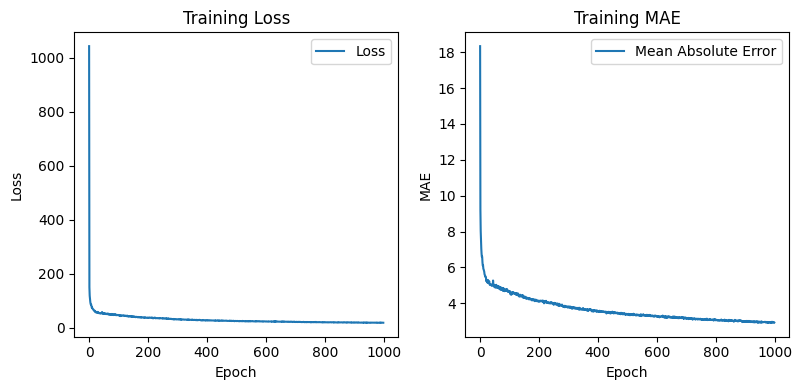

In [ ]:
def custom_accuracy(y_true, y_pred, tolerance=0.1):
    # Calculate the absolute difference between predictions and true values
    diff = tf.abs(y_true - y_pred)
    # Check if the difference is within the tolerance level for each prediction
    within_tolerance = tf.less_equal(diff, tolerance * y_true)
    # Calculate mean accuracy across all dimensions
    return tf.reduce_mean(tf.cast(within_tolerance, tf.float32))

# Compile model with the custom accuracy metric
model.compile(optimizer='adam', loss='mse', metrics=['mae', custom_accuracy])

import matplotlib.pyplot as plt

# Plot loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

# Plot mean absolute error (MAE)
plt.subplot(1, 3, 2)
plt.plot(history.history['mae'], label='Mean Absolute Error')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.title('Training MAE')
plt.legend()

# Plot custom accuracy (if defined)
if 'custom_accuracy' in history.history:
    plt.subplot(1, 3, 3)
    plt.plot(history.history['custom_accuracy'], label='Custom Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy')
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Cargar el modelo previamente guardado
model = tf.keras.models.load_model("model_1.keras", custom_objects={'custom_accuracy': custom_accuracy})

# Preparar los datos de prueba
testA_data = testA_subject_to_photo_df.merge(testA_hwg_metadata_df, on='subject_id').merge(testA_measurements_df, on='subject_id')
testA_data['frontal_image_path'] = testA_mask_dir + '/' + testA_data['photo_id'] + '.png'
testA_data['lateral_image_path'] = testA_mask_left_dir + '/' + testA_data['photo_id'] + '.png'

# Generar predicciones
predictions = []
for _, row in testA_data.iterrows():
    if os.path.exists(row['frontal_image_path']) and os.path.exists(row['lateral_image_path']):
        frontal_image = tf.keras.preprocessing.image.load_img(row['frontal_image_path'], target_size=(224, 224), color_mode='grayscale')
        lateral_image = tf.keras.preprocessing.image.load_img(row['lateral_image_path'], target_size=(224, 224), color_mode='grayscale')

        # Convertir a arrays y concatenar en un input de 2 canales
        frontal_image = tf.keras.preprocessing.image.img_to_array(frontal_image)
        lateral_image = tf.keras.preprocessing.image.img_to_array(lateral_image)
        combined_image = np.concatenate([frontal_image, lateral_image], axis=-1) / 255.0  # Normalizar

        # Agregar height y weight como entradas adicionales
        additional_inputs = np.array([[row['height_cm'], row['weight_kg']]], dtype=np.float32)

        # Realizar la predicción
        pred = model.predict([np.expand_dims(combined_image, axis=0), additional_inputs])
        predictions.append([row['subject_id']] + pred[0].tolist())

# Crear un DataFrame con las predicciones
columns = ['subject_id', 'ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm',
           'height', 'hip', 'leg-length', 'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 'wrist']
pred_df = pd.DataFrame(predictions, columns=columns)

# Guardar las predicciones en un archivo CSV
pred_df.to_csv('predictions_testA.csv', index=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━

In [ ]:
# Cargar el modelo previamente guardado
model = tf.keras.models.load_model("model_1.keras", custom_objects={'custom_accuracy': custom_accuracy})

# Preparar los datos de prueba
testA_data = testA_subject_to_photo_df.merge(testA_hwg_metadata_df, on='subject_id').merge(testA_measurements_df, on='subject_id')
testA_data['frontal_image_path'] = testA_mask_dir + '/' + testA_data['photo_id'] + '.png'
testA_data['lateral_image_path'] = testA_mask_left_dir + '/' + testA_data['photo_id'] + '.png'

# Filtrar las filas donde las imágenes existen
testA_data = testA_data[testA_data['frontal_image_path'].apply(os.path.exists) & testA_data['lateral_image_path'].apply(os.path.exists)]

# Preparar las imágenes y entradas adicionales para todas las filas en un solo paso
images = []
additional_inputs = []

for _, row in testA_data.iterrows():
    # Cargar y procesar las imágenes frontal y lateral
    frontal_image = tf.keras.preprocessing.image.load_img(row['frontal_image_path'], target_size=(224, 224), color_mode='grayscale')
    lateral_image = tf.keras.preprocessing.image.load_img(row['lateral_image_path'], target_size=(224, 224), color_mode='grayscale')

    # Convertir a arrays y concatenar en un input de 2 canales
    frontal_image = tf.keras.preprocessing.image.img_to_array(frontal_image)
    lateral_image = tf.keras.preprocessing.image.img_to_array(lateral_image)
    combined_image = np.concatenate([frontal_image, lateral_image], axis=-1) / 255.0  # Normalizar
    images.append(combined_image)

    # Agregar height y weight como entradas adicionales
    additional_inputs.append([row['height_cm'], row['weight_kg']])

# Convertir a arrays numpy para usar en el modelo
images = np.array(images, dtype=np.float32)
additional_inputs = np.array(additional_inputs, dtype=np.float32)

# Realizar todas las predicciones de una sola vez
predictions = model.predict([images, additional_inputs])

# Crear un DataFrame con las predicciones
columns = ['ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'height', 'hip', 'leg-length',
           'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 'wrist']
pred_df = pd.DataFrame(predictions, columns=columns)
pred_df['subject_id'] = testA_data['subject_id'].values  # Añadir los subject_id

# Guardar las predicciones en un archivo CSV
pred_df.to_csv('predictions_testA.csv', index=False)


53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step


In [ ]:
# Cargar los datos reales de testA
testA_real = pd.read_csv('/content/BodyM_dataset/testA/measurements.csv')

# Cargar las predicciones de testA
testA_pred = pd.read_csv('/content/predictions_testA.csv')

In [ ]:
# Combinar los datos reales y las predicciones
comparison_df = testA_real.merge(testA_pred, on='subject_id', suffixes=('_real', '_pred'))

In [ ]:
# Calcular el error relativo (porcentual) para cada medida
error_percentages = {}
for column in ['ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'height', 'hip',
               'leg-length', 'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 'wrist']:
    real_col = f"{column}_real"
    pred_col = f"{column}_pred"
    comparison_df[f'{column}_error_percent'] = ((comparison_df[pred_col] - comparison_df[real_col]) / comparison_df[real_col]) * 100

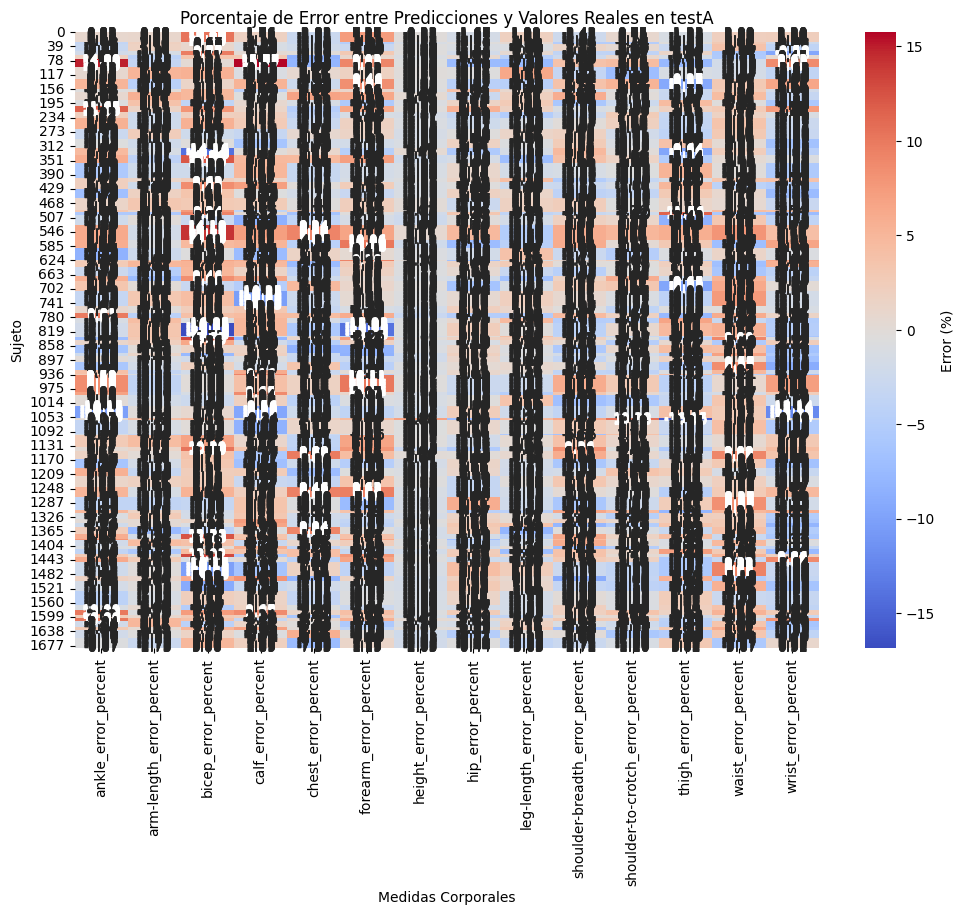

In [ ]:
# Seleccionar solo las columnas de porcentaje de error
error_columns = [col for col in comparison_df.columns if '_error_percent' in col]
error_df = comparison_df[error_columns]

# Crear el heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(error_df, annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={'label': 'Error (%)'})
plt.title("Porcentaje de Error entre Predicciones y Valores Reales en testA")
plt.xlabel("Medidas Corporales")
plt.ylabel("Sujeto")
plt.show()

<Axes: >

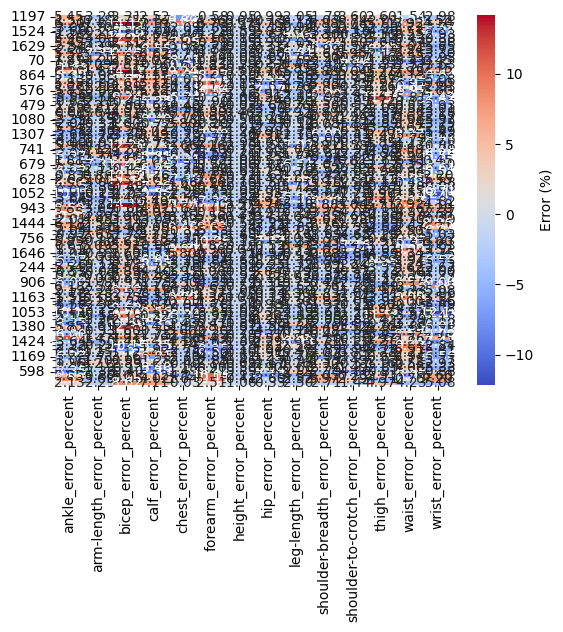

In [ ]:
sample_comparison_df = comparison_df.sample(100, random_state=42)  # Tomar una muestra de 100 sujetos
sns.heatmap(sample_comparison_df[error_columns], annot=True, cmap='coolwarm', fmt=".2f", cbar_kws={'label': 'Error (%)'})

<Axes: >

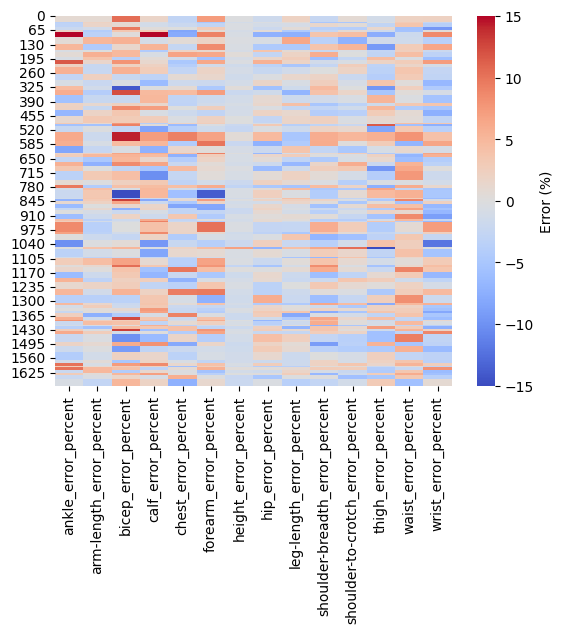

In [ ]:
sns.heatmap(error_df, annot=False, cmap='coolwarm', fmt=".2f", cbar_kws={'label': 'Error (%)'}, vmin=-15, vmax=15)

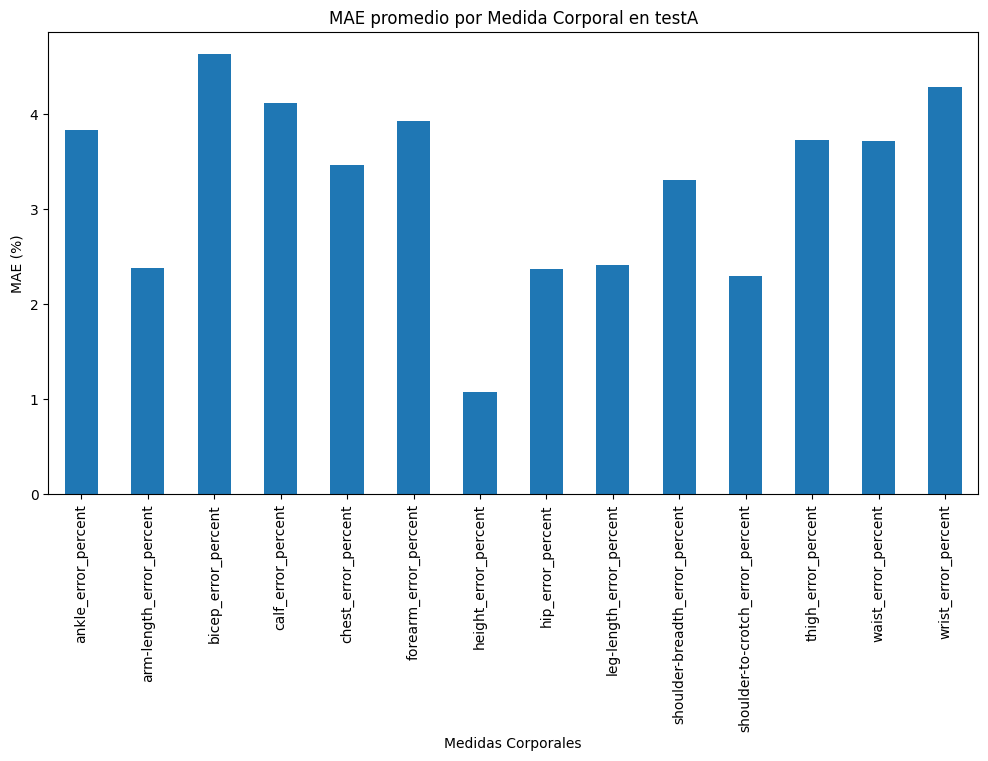

In [ ]:
# Calcular el MAE promedio para cada medida
mae = error_df.abs().mean()

plt.figure(figsize=(12, 6))
mae.plot(kind='bar')
plt.xlabel("Medidas Corporales")
plt.ylabel("MAE (%)")
plt.title("MAE promedio por Medida Corporal en testA")
plt.show()

In [ ]:
import numpy as np
import pandas as pd

# Suponiendo que `comparison_df` ya contiene los valores reales y predichos de cada medida
# Definimos una tolerancia del 10% (esto se puede ajustar según tus necesidades)
tolerance = 0.10

# Calcular el accuracy por cada medida, considerando como "correcto" un error menor al 10%
accuracy_results = {}
for column in ['ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'height', 'hip',
               'leg-length', 'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 'wrist']:
    real_col = f"{column}_real"
    pred_col = f"{column}_pred"
    # Calcular el error relativo
    relative_error = abs((comparison_df[pred_col] - comparison_df[real_col]) / comparison_df[real_col])
    # Calcular el accuracy basado en la tolerancia
    accuracy_results[column] = (relative_error <= tolerance).mean() * 100  # Porcentaje de aciertos dentro de la tolerancia

# Accuracy promedio de todas las medidas
average_accuracy = np.mean(list(accuracy_results.values()))
print("Accuracy promedio:", average_accuracy)
print("Accuracy por medida:", accuracy_results)

Accuracy promedio: 97.73922633186291
Accuracy por medida: {'ankle': 94.47743467933492, 'arm-length': 100.0, 'bicep': 86.99524940617577, 'calf': 96.37767220902613, 'chest': 100.0, 'forearm': 93.88361045130641, 'height': 100.0, 'hip': 100.0, 'leg-length': 100.0, 'shoulder-breadth': 100.0, 'shoulder-to-crotch': 99.58432304038006, 'thigh': 98.99049881235155, 'waist': 100.0, 'wrist': 98.04038004750593}


In [ ]:
# Calcular la media y desviación estándar del error relativo para cada medida
error_deviation = {}
for column in ['ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'height', 'hip',
               'leg-length', 'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 'wrist']:
    real_col = f"{column}_real"
    pred_col = f"{column}_pred"
    # Calcular el error relativo
    relative_error = abs((comparison_df[pred_col] - comparison_df[real_col]) / comparison_df[real_col])
    # Calcular media y desviación estándar
    error_mean = relative_error.mean()
    error_std = relative_error.std()
    # Contar cuántos valores están fuera de 1 desviación estándar
    outliers_1std = (relative_error > (error_mean + error_std)).sum()
    outliers_2std = (relative_error > (error_mean + 2 * error_std)).sum()

    error_deviation[column] = {
        "Error Medio (%)": error_mean * 100,
        "Desviación Estándar (%)": error_std * 100,
        "Fuera de 1 STD": outliers_1std,
        "Fuera de 2 STD": outliers_2std
    }

# Convertir los resultados a un DataFrame para una visualización más clara
error_deviation_df = pd.DataFrame(error_deviation).T
print(error_deviation_df)

                    Error Medio (%)  Desviación Estándar (%)  Fuera de 1 STD  \
ankle                      3.830352                 2.971228           205.0   
arm-length                 2.375264                 1.697648           291.0   
bicep                      4.627723                 3.952278           287.0   
calf                       4.111202                 2.987497           311.0   
chest                      3.460048                 2.539060           274.0   
forearm                    3.924297                 3.198970           328.0   
height                     1.070505                 0.737425           284.0   
hip                        2.369854                 1.791083           315.0   
leg-length                 2.404455                 1.854601           306.0   
shoulder-breadth           3.299829                 2.082115           382.0   
shoulder-to-crotch         2.296500                 1.848736           294.0   
thigh                      3.726325     

# CONCLUSIONES:

1. Accuracy Promedio
El accuracy promedio es de 97.74%, lo cual indica que, en promedio, las predicciones del modelo están dentro de la tolerancia establecida para el 97.74% de las medidas en testA. Esto es un resultado bastante bueno y sugiere que el modelo tiene un desempeño sólido en general.
2. Accuracy por Medida
Analizando el accuracy por cada medida:
Medidas con 100% de Accuracy: arm-length, chest, height, hip, leg-length, shoulder-breadth, y waist. Esto significa que el modelo logró predecir estas medidas dentro de la tolerancia en todos los casos de testA.
Medidas con Accuracy menor a 100%:
bicep tiene el accuracy más bajo con un 86.99%, lo que sugiere que esta es una medida difícil para el modelo y podría necesitar optimización.
Otras medidas, como ankle, calf, forearm, thigh, y wrist, tienen un accuracy entre el 90% y el 99%, lo cual sigue siendo bastante aceptable pero muestra un margen de mejora en algunas áreas.
3. Error Medio y Desviación Estándar
Error Medio: La columna de error medio en el primer gráfico muestra que la medida bicep tiene uno de los errores más altos, lo cual concuerda con su accuracy más bajo. Medidas como height y shoulder-to-crotch tienen errores medios bajos, indicando que el modelo predice estas con mayor precisión.
Desviación Estándar: La desviación estándar del error muestra qué tan dispersos están los errores alrededor de la media. Una desviación estándar alta (como en bicep y calf) indica una variabilidad mayor en las predicciones, lo que podría ser un área de mejora.
4. Fuera de 1 y 2 Desviaciones Estándar
Los datos de la columna "Fuera de 1 STD" y "Fuera de 2 STD" en el primer gráfico muestran cuántas predicciones están fuera de 1 o 2 desviaciones estándar de la media.
Por ejemplo, ankle, bicep, y calf tienen muchos valores fuera de 2 desviaciones estándar, lo que sugiere que hay sujetos específicos en testA para los cuales el modelo tiene dificultades en predecir estas medidas con consistencia.
5. MAE Promedio por Medida (Gráfico de Barras)
El gráfico de barras muestra el MAE (Error Absoluto Medio) en porcentaje para cada medida corporal. bicep y calf destacan con los valores más altos de MAE, lo cual refuerza el hallazgo de que estas medidas tienen un desempeño más débil comparado con otras.
Medidas como height, shoulder-to-crotch, y shoulder-breadth tienen los valores más bajos de MAE, lo que indica una alta precisión en estas áreas.
6. Heatmap de Errores
El heatmap muestra la distribución del error relativo en porcentaje para cada medida y cada sujeto. Las celdas en color rojo o azul intenso indican valores de error más extremos, lo que puede señalar outliers o áreas en las que el modelo no se ajusta bien.
Puedes observar que las áreas rojas o azules aparecen más en bicep y calf, lo cual es consistente con los resultados de MAE y desviación estándar.
Conclusiones Generales
Desempeño General: El modelo tiene un buen desempeño general en testA, con un accuracy promedio de 97.74%.
Medidas Consistentes: Medidas como height, shoulder-to-crotch, y shoulder-breadth son predichas de manera precisa y consistente.
Áreas de Mejora: bicep, calf, y forearm muestran mayores errores y variabilidad en las predicciones. Estas medidas podrían beneficiarse de ajustes en el modelo, como aumentar el tamaño del dataset o ajustar hiperparámetros específicos para mejorar su precisión.
